# Tabular classification with `LanguageModelClassifier`

`LanguageModelClassifier` is the classification view of the shared fine-tune introduced in
`00-intro.ipynb`: one autoregressive LM trained over permuted column orders, so it learns
$p(x_j \mid x_S)$ for any column $j$ and any subset $S$. Here the prompt $x_S$ is all the features
and the target $x_j$ is the class label.

## How classification works

A classifier needs a valid label and a calibrated probability — free-form generation gives neither.
So `LanguageModelClassifier` **scores**, it does not generate. For a row $x$ and each candidate
class $c \in \mathcal{C}$ (the fitted `classes_`), it forms the serialized string with `target = c`
and reads off the model's mean per-token log-likelihood of the class tokens,

$$ \ell(c) = \frac{1}{|c|}\sum_{i} \log p_\theta\!\left(t_i \mid t_{<i}\right), $$

then normalizes over the *fixed* candidate set with a softmax:

$$ \hat{p}(y = c \mid x) = \frac{e^{\ell(c)}}{\sum_{c' \in \mathcal{C}} e^{\ell(c')}},
\qquad \hat{y} = \arg\max_{c \in \mathcal{C}}\, \hat{p}(c \mid x). $$

Two consequences: every prediction is a member of `classes_` (an invalid label is impossible),
and `predict_proba` returns a genuine distribution that sums to 1. Because scoring is
deterministic, the sampling knobs in `GenerationConfig` (`temperature`, `top_p`, …) have no
effect on the classifier.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklm import (
    GenerationConfig,
    JSONSerializer,
    LanguageModelClassifier,
    LoRAConfig,
    SpacedDigits,
    TrainingConfig,
    RichCallback, IfThenSerializer
)

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data

Iris: four length measurements in centimetres, three species. We strip the `(cm)` suffix to keep
the serialized text compact, and split with stratification so each class keeps its proportion in
both train and test.

In [2]:
data = load_iris(as_frame=True)
X = data.data.rename(columns=lambda c: c.removesuffix(" (cm)"))
y = data.target_names[data.target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train.head()

,sepal length,sepal width,petal length,petal width
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


## Fine-tuning

`augmentation_factor=24` means each row is shown under 24 random column orderings per epoch —
this is the permutation augmentation that teaches the conditional structure. `backend="mlx"`
runs on Apple Silicon; `backend="auto"` picks the installed stack (HF/MLX) by platform.
`JupyterCallback` renders a live training curve and sample predictions inline.

In [3]:
clf = LanguageModelClassifier(
    backend="mlx",
    model="gabfssilva/distilgpt2",
    precision="fp32",
    training=TrainingConfig(
        epochs=10,
        batch_size=16,
        lr_scheduler="cosine",
        weight_decay=0.5,
        learning_rate=2e-5,
        augmentation_factor=24,
        loss_on_target_only=True,
        label_smoothing=0.03
    ),
    generation=GenerationConfig(n_samples=24),
    random_state=SEED
)
clf.fit(X_train, y_train)

,model,'gabfssilva/distilgpt2'
,attn_implementation,None
,backend,'mlx'
,callback,None
,device,'auto'
,generation__aggregate,<function agg...t 0x110c844a0>
,generation__candidate_scoring,'mean'
,generation__inference_batch_size,None
,generation__max_new_tokens,None
,generation__n_samples,24
,generation__permute_order,False


## Evaluation

In [4]:
pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.3f}")

HTML(value='')

accuracy: 0.900


The confusion matrix breaks accuracy down per class: cell $(i, j)$ counts test rows whose true
class is $i$ and predicted class is $j$, so the diagonal is correct and off-diagonal cells are
the mistakes.

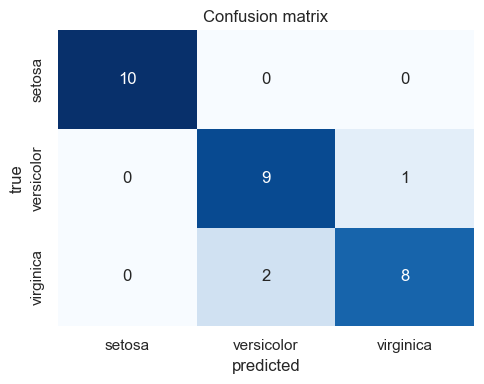

In [5]:
cm = confusion_matrix(y_test, pred, labels=clf.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

## A genuine probability distribution

Because the classifier scores a fixed candidate set, `predict_proba` is a calibrated
distribution over `classes_`: each row's bars sum to 1.

HTML(value='')

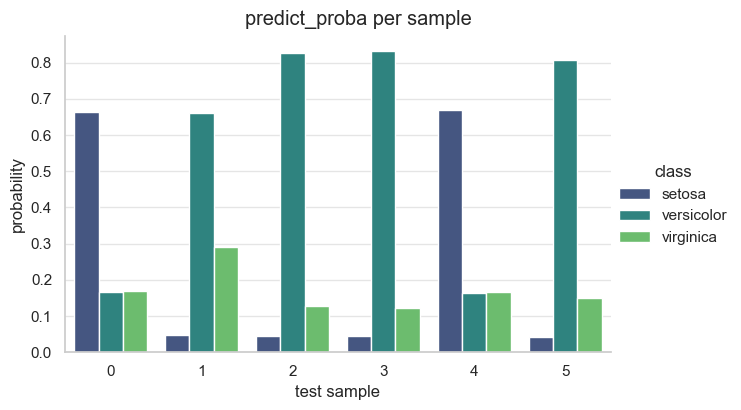

In [6]:
proba = clf.predict_proba(X_test)
proba_df = (
    pd.DataFrame(proba, columns=clf.classes_)
    .head(6)
    .reset_index(names="sample")
    .melt(id_vars="sample", var_name="class", value_name="probability")
)

g = sns.catplot(
    proba_df, kind="bar", x="sample", y="probability", hue="class",
    height=4, aspect=1.6, palette="viridis",
)
g.set_axis_labels("test sample", "probability")
g.figure.suptitle("predict_proba per sample", y=1.02)
plt.show()